# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

https://1drv.ms/v/c/808ebfd9a0d86213/IQCLY6g2vuPjQr-7RxF_QZK0AWue-PxKWmQ8QlMEtwIh2WA?e=qBwOpD

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from Bio import Entrez

Entrez.email = "matcow53@gmail.com"
print("ok")

ok


In [7]:
genes = pd.read_csv('/home/nina/Documents/Aula git/Data/array_ex7_aula6.csv', index_col=0, header=0)
genes

,n_caracteres,2_primeiras_letras,n_a,hu
ROP16,5,RO,0,False
ROP18,5,RO,0,False
GRA7,4,GR,0,False
SAG2,4,SA,0,False
IL6,3,IL,0,False


In [8]:
from Bio import SeqIO

In [16]:
gene_ids = {
    "ROP16": ("protein", "XP_002365373.1"),
    "ROP18": ("protein", "XP_002367716.1"),
    "GRA7":  ("protein", "XP_002367572.1"),
    "SAG2":  ("nucleotide", "JX045478.1"),
    "IL6":   ("protein", "NP_000600.1")}

dados = []
for sigla, (db, codigo) in gene_ids.items():
    handle = Entrez.efetch(db=db, id=codigo, rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    handle.close()

    dados.append({
        "Sigla": sigla,
        "Código": codigo,
        "Sequência": str(record.seq)
    })

df_final = pd.DataFrame(dados)
print("\nDataFrame final:")
print(df_final)


DataFrame final:
   Sigla          Código                                          Sequência
0  ROP16  XP_002365373.1  MKVTTKGLAFALALLFCTRCATARYMSFEEAQKASEAAKRQIATLP...
1  ROP18  XP_002367716.1  MPPEGGRRSREPRPSFSVSFASCPALEEPERGDTPGSPGSEERRQD...
2   GRA7  XP_002367572.1  MPFDPSRWMTQRHSHPRIGPAYQAPIPDCIRDVSESPRVPAEWLEG...
3   SAG2      JX045478.1  ATGAGTTTCTCAAAGACCACGAGCCTAGCGTCGCTAGCGCTCACGG...
4    IL6     NP_000600.1  MNAKVVVVLVLVLTALCLSDGKPVSLSYRCPCRFFESHVARANVKH...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [ ]:
from collections import Counter

freqs = []
for _, row in df_final.iterrows():
    contagem = Counter(row["Sequência"])
    contagem["Sigla"] = row["Sigla"]
    freqs.append(contagem)

df_freqs = pd.DataFrame(freqs).fillna(0)
print(df_freqs)



      M     K     V    T    G      L    A     F    C      R  ...      S     E  \
0  14.0  27.0  50.0   36   47   69.0   76  21.0    7   47.0  ...   82.0  46.0   
1   9.0  26.0  50.0   50   66  103.0  109  46.0   17  113.0  ...  122.0  70.0   
2   2.0  12.0  17.0   20   51   19.0   44   8.0    6   30.0  ...   37.0  48.0   
3   0.0   0.0   0.0  143  151    0.0  112   0.0  155    0.0  ...    0.0   0.0   
4   2.0  10.0  11.0    2    1   13.0    7   3.0    5    6.0  ...    4.0   3.0   

      Q     I     P     D     N     H    W  Sigla  
0  42.0  18.0  54.0  20.0  18.0  13.0  5.0  ROP16  
1  43.0  17.0  73.0  52.0  17.0  25.0  2.0  ROP18  
2  15.0   8.0  22.0  20.0   5.0   8.0  3.0   GRA7  
3   0.0   0.0   0.0   0.0   0.0   0.0  0.0   SAG2  
4   3.0   4.0   4.0   2.0   8.0   2.0  1.0    IL6  

[5 rows x 21 columns]


In [27]:
df_freqs.to_csv("frequencias_aminoacidos.csv", index=False)

## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [18]:
df_freqs["Valina"] = df_freqs["V"]
print(df_freqs[["Sigla", "Valina"]])

gene_max_valina = df_freqs.loc[df_freqs["Valina"].idxmax()]
print("Gene com mais Valinas:", gene_max_valina["Sigla"])

   Sigla  Valina
0  ROP16    50.0
1  ROP18    50.0
2   GRA7    17.0
3   SAG2     0.0
4    IL6    11.0
Gene com mais Valinas: ROP16


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [19]:
serinas = df_freqs["S"]

media = serinas.mean()
mediana = serinas.median()
moda = serinas.mode()[0]

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda)

Média: 49.0
Mediana: 37.0
Moda: 0.0


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

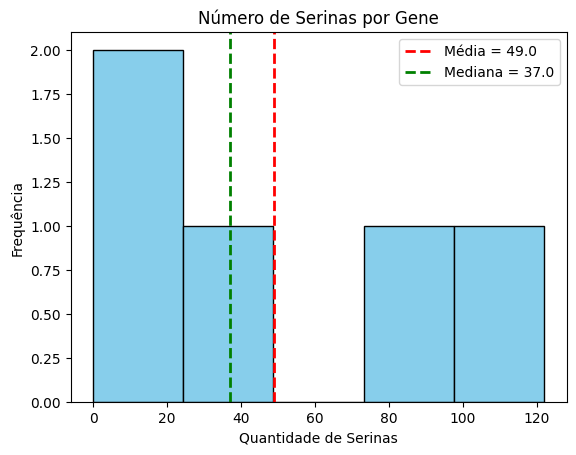

In [20]:

plt.hist(serinas, bins=5, color="skyblue", edgecolor="black")
plt.axvline(media, color="red", linestyle="dashed", linewidth=2, label=f"Média = {media}")
plt.axvline(mediana, color="green", linestyle="dashed", linewidth=2, label=f"Mediana = {mediana}")
plt.legend()
plt.title("Número de Serinas por Gene")
plt.xlabel("Quantidade de Serinas")
plt.ylabel("Frequência")
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

Aminoácido: S
Média: 49.0
Mediana: 37.0
Moda: 0.0


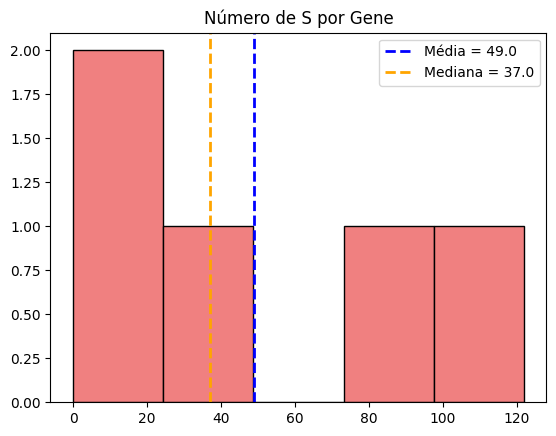

In [22]:
def analisa_aminoacido(df_freqs, aa):
    valores = df_freqs[aa]
    media = valores.mean()
    mediana = valores.median()
    moda = valores.mode()[0]
    
    print(f"Aminoácido: {aa}")
    print("Média:", media)
    print("Mediana:", mediana)
    print("Moda:", moda)
    
    plt.hist(valores, bins=5, color="lightcoral", edgecolor="black")
    plt.axvline(media, color="blue", linestyle="dashed", linewidth=2, label=f"Média = {media}")
    plt.axvline(mediana, color="orange", linestyle="dashed", linewidth=2, label=f"Mediana = {mediana}")
    plt.legend()
    plt.title(f"Número de {aa} por Gene")
    plt.show()

analisa_aminoacido(df_freqs, "S") 

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

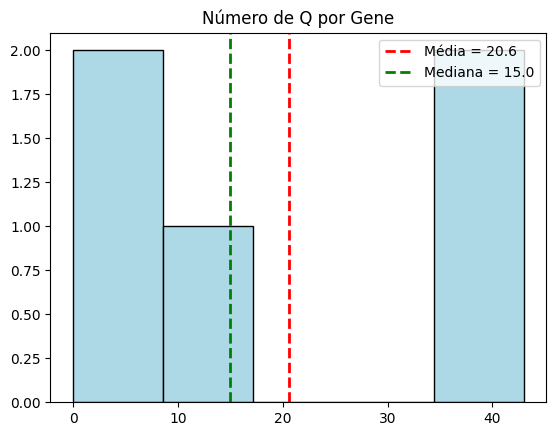

Q: Diferença entre média e mediana = 5.600000000000001


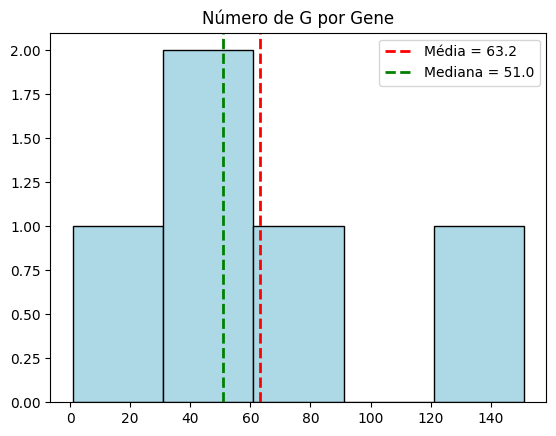

G: Diferença entre média e mediana = 12.200000000000003


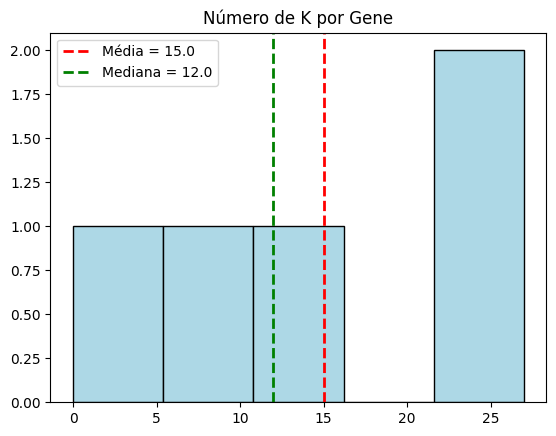

K: Diferença entre média e mediana = 3.0


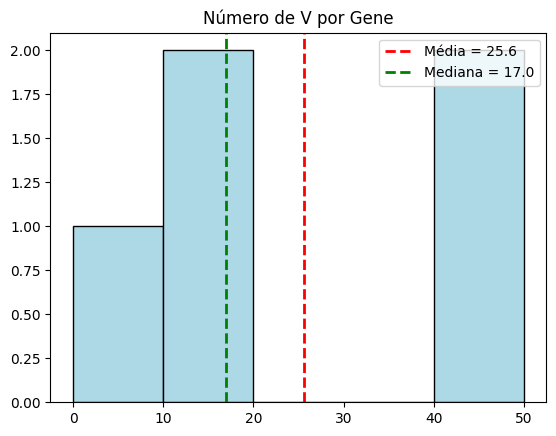

V: Diferença entre média e mediana = 8.600000000000001


In [23]:
aas = ["Q", "G", "K", "V"]

for aa in aas:
    valores = df_freqs[aa]
    media = valores.mean()
    mediana = valores.median()
    
    plt.hist(valores, bins=5, color="lightblue", edgecolor="black")
    plt.axvline(media, color="red", linestyle="dashed", linewidth=2, label=f"Média = {media}")
    plt.axvline(mediana, color="green", linestyle="dashed", linewidth=2, label=f"Mediana = {mediana}")
    plt.legend()
    plt.title(f"Número de {aa} por Gene")
    plt.show()
    
    print(f"{aa}: Diferença entre média e mediana = {abs(media - mediana)}")

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [ ]:
cisteina = df_freqs.loc[:2, "C"]
print("Média:", cisteina.mean())
print("Mediana:", cisteina.median())

Média: 10.0
Mediana: 7.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [25]:
df_freqs["Média_AA"] = df_freqs.drop(columns=["Sigla"]).mean(axis=1)
gene_maior = df_freqs.loc[df_freqs["Média_AA"].idxmax()]
print("Maior gene:", gene_maior["Sigla"], "com média de", gene_maior["Média_AA"])

Maior gene: ROP18 com média de 50.857142857142854


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [26]:
gene_menor = df_freqs.loc[df_freqs["Média_AA"].idxmin()]
print("Menor gene:", gene_menor["Sigla"], "com média de", gene_menor["Média_AA"])

Menor gene: IL6 com média de 4.9523809523809526
